In [ ]:
# Data-path configuration (see ../paths.py and ../DATA.md).
# Set the SCREAM_AUTOTUNE_DATA env var to point at the unpacked Zenodo
# data deposit; defaults to <repo>/data. Assumes this notebook is run
# from its own directory (the Jupyter default).
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import paths


# Abbreviated surrogate training workflow

The below is implimented in a python file '/global/cfs/cdirs/e3sm/jpaige3/optimizing/run_GPsurrogate_fromsave.py'

The documentation for ESEm is at https://esem.readthedocs.io/en/latest/

In [1]:
import os
import json
import math
import pandas as pd
import numpy as np
import xarray as xr
import sklearn
import glob
import pickle
from esem import gp_model
from esem.utils import get_random_params, plot_results, prettify_plot, add_121_line, leave_one_out
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, r2_score
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline

#import gpflow
#import tensorflow as tf
import importlib.util
from datetime import date
from datetime import datetime
import timeit
from timeit import default_timer as timer

from concurrent.futures import ThreadPoolExecutor

from scipy.optimize import basinhopping
from scipy.optimize import minimize
import csv

#address warning messages: pip install tensorflow[and-cuda]

2026-06-19 13:33:01.156647: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 13:33:01.156688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 13:33:01.159022: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 13:33:01.166649: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/global/homes/j/jpaige3/.conda/env

In [2]:
DY1_obs_dir = str(paths.DY1_OBS_DIR) + '/'
DY1_precip_obs_file = DY1_obs_dir + 'IMERG.precip_total_surf_mass_flux.daily_AVERAGE.ne30pg2.20160807_mahf708.nc' #maybe check this
DY1_LW_obs_file = DY1_obs_dir + 'CERES.LW_flux_up_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
#DY1_SW_dn_obs_file = DY1_obs_dir + 'CERES.SW_flux_dn_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
DY1_SW_up_obs_file = DY1_obs_dir + 'CERES.SW_flux_up_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
DY1_LWP_file = DY1_obs_dir + 'mac.clwp-tlwp-wvp.20160807.ne30pg2.nc'

DY1_PCP_obs = xr.open_dataset(DY1_precip_obs_file).variables['precip_total_surf_mass_flux'].squeeze('time')
DY1_TLWP_obs = (xr.open_dataset(DY1_LWP_file).variables['tlwp']*1e-3).squeeze('time')
DY1_OSR_obs = xr.open_dataset(DY1_SW_up_obs_file).variables['SW_flux_up_at_model_top'].squeeze('time')
DY1_OLR_obs = xr.open_dataset(DY1_LW_obs_file).variables['LW_flux_up_at_model_top'].squeeze('time')

In [3]:
DY2_obs_dir = str(paths.DY2_OBS_DIR) + '/'
DY2_precip_obs_file = DY2_obs_dir + 'IMERG.precip_total_surf_mass_flux.AVERAGE.ne30pg2.20200126.nc'
DY2_LW_obs_file = DY2_obs_dir + 'CERES.LW_flux_up_at_model_top.AVERAGE.ne30pg2.20200126.nc'
#DY2_SW_dn_obs_file = DY2_obs_dir + 'CERES.SW_flux_dn_at_model_top.AVERAGE.ne30pg2.20200126.nc'
DY2_SW_up_obs_file = DY2_obs_dir + 'CERES.SW_flux_up_at_model_top.AVERAGE.ne30pg2.20200126.nc'
DY2_LWP_file = DY2_obs_dir + 'mac.clwp-tlwp-wvp.20200126.ne30pg2.nc'

DY2_PCP_obs = xr.open_dataset(DY2_precip_obs_file).variables['precip_total_surf_mass_flux'].squeeze('time')
DY2_TLWP_obs = (xr.open_dataset(DY2_LWP_file).variables['tlwp']*1e-3).squeeze('time')
DY2_OSR_obs = xr.open_dataset(DY2_SW_up_obs_file).variables['SW_flux_up_at_model_top'].squeeze('time')
DY2_OLR_obs = xr.open_dataset(DY2_LW_obs_file).variables['LW_flux_up_at_model_top'].squeeze('time')

In [4]:
##two ways to get these masks
mask_path =str(paths.MASK_DIR) + '/'

DY1_PCP_mask = xr.open_dataset(mask_path+'/masks/precip_1_output.nc').squeeze('time', drop=True)
DY2_PCP_mask = xr.open_dataset(mask_path+'/masks/precip_2_output.nc').squeeze('time', drop=True)
DY1_TLWP_mask = xr.open_dataset(mask_path+'/masks/tlwp_1_output.nc').squeeze('time', drop=True)
DY2_TLWP_mask = xr.open_dataset(mask_path+'/masks/tlwp_2_output.nc').squeeze('time', drop=True)

#len(np.where(((DY1_TLWP_mask.to_dataarray()[0]) == True).values)[0]) - ncol drops from 21600 to 15313

In [5]:
regions_file = xr.open_dataset(str(paths.REGIONS_FILE))
regions_list = ['poles','extratropical_land','extratropical_ocean','tropical_land','ascending_tropical_ocean','descending_tropical_ocean']
#area = ppe_dataset.area[1,:] #only taking the first row, because all rows should have the same values
control = xr.open_dataset(str(paths.CONTROL_FILE))
area = control.variables['area'][:]
lat = control.variables['lat'][:]
lon = control.variables['lon'][:]

## Restarting from saved model/data

Load in regions and define zones to take geographical averages

In [6]:
def zonal_means_native(data, area, lat, lon):
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    lat = lat.squeeze()
    lat_bands = np.linspace(-90, 90, 19) #currently dividing globe in 18 zones via 19 borders - 10 degree bands
    zonal_means = dict()
    for i in range(len(lat_bands) - 1):
        mask_zone = (lat >= lat_bands[i]) & (lat < lat_bands[i+1]) #includes lower bound in the band (! might cause missing north pole)
        data_zone = np.where(mask_zone, data, np.nan)
        area_zone = np.where(mask_zone, masked_area, np.nan)
        zone_center = lat_bands[i] + (lat_bands[i+1] - lat_bands[i])/2
        if np.all(np.isnan(data_zone)) or np.nansum(area_zone) == 0:
            zonal_means[zone_center] = np.nan
        else:
            zone_mean = np.nansum(data_zone * area_zone) / np.nansum(area_zone)
            zonal_means[zone_center] = zone_mean
    return zonal_means

def regional_means_native(data, area, region_data):  
    #region_data = xr.open_dataset('/global/cfs/projectdirs/e3smdata/simulations/ecp-autotune/regions.nc') #for performance improvement move region_data out as argument
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    regions_list = ['poles', 'extratropical_land', 'extratropical_ocean', 
                    'tropical_land', 'ascending_tropical_ocean', 'descending_tropical_ocean']
    region_means = dict()
    for reg_name in regions_list:
        mask_reg = region_data[reg_name].squeeze()
        data_reg = np.where(mask_reg > 0, data, np.nan)
        area_reg = np.where(mask_reg > 0, masked_area, np.nan)
        if np.all(np.isnan(data_reg)) or np.nansum(area_reg) == 0:
            region_means[reg_name] = np.nan
        else:
            reg_mean = np.nansum(data_reg * area_reg) / np.nansum(area_reg)
            region_means[reg_name] = reg_mean
    return region_means

def global_means_native(data, area): #takes global averages
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    global_mean = np.nansum(data*masked_area)/np.nansum(masked_area)
    return global_mean

In [ ]:
#load back observations
obs_filename = str(paths.OBS_PICKLE)

with open(obs_filename, 'rb') as f:
    loaded_obs = pickle.load(f)
    
zrg_obs = loaded_obs['zrg_obs']
PCP_zrg_obs = loaded_obs['PCP_zrg_obs']
TLWP_zrg_obs = loaded_obs['TLWP_zrg_obs']
OSR_zrg_obs = loaded_obs['OSR_zrg_obs']
OLR_zrg_obs = loaded_obs['OLR_zrg_obs']
n_cols_per_df = zrg_obs.shape[1] // 4 #50 DY1 and DY2

In [ ]:
# Load back GP proj
GP_proj_filename = str(paths.GP_PROJ_PICKLE)

with open(GP_proj_filename, 'rb') as f:
    loaded = pickle.load(f)

# Access data
train_run_labels = loaded['X_train_index']
X_pipe_sk_minmax = loaded['X_pipeline']
Y_pipe_sk_ss_PCP = loaded['Y_pipeline_PCP']
Y_pipe_sk_ss_TLWP = loaded['Y_pipeline_TLWP']
Y_pipe_sk_ss_OSR = loaded['Y_pipeline_OSR']
Y_pipe_sk_ss_OLR = loaded['Y_pipeline_OLR']
### normalized/transformed
X_train_norm = loaded['X_train_norm']
Y_train_norm = loaded['Y_train_norm']
PCP_train_norm = loaded['PCP_train_norm']
TLWP_train_norm = loaded['TLWP_train_norm']
OSR_train_norm = loaded['OSR_train_norm']
OLR_train_norm = loaded['OLR_train_norm']
### unnormalized/untransformed
X_train = loaded['X_train']
Y_train_ZRG = loaded['Y_train']
PCP_train = loaded['PCP_train']
TLWP_train = loaded['TLWP_train']
OSR_train = loaded['OSR_train']
OLR_train = loaded['OLR_train']

In [9]:
print(X_train_norm.shape, Y_train_norm.shape)

(153, 16) (153, 44, 4)


In [10]:
areas_to_remove = ['DY1_85.0', 'DY1_-85.0', 'DY1_-75.0', 'DY2_85.0', 'DY2_-85.0', 'DY2_-75.0']

The observational dataset and the training dataset (the full ppe in this case) have been loaded in. They are composed of DY1 and DY2 data with zonal, regional, and global data. They are separated by target variable so (for independent normalization).

In [11]:
PCP_obs_norm = Y_pipe_sk_ss_PCP.transform(PCP_zrg_obs)
TLWP_obs_norm = Y_pipe_sk_ss_TLWP.transform(TLWP_zrg_obs)
OSR_obs_norm = Y_pipe_sk_ss_OSR.transform(OSR_zrg_obs)
OLR_obs_norm = Y_pipe_sk_ss_OLR.transform(OLR_zrg_obs)

obs_norm = np.stack([PCP_obs_norm, TLWP_obs_norm, OSR_obs_norm, OLR_obs_norm])
obs_norm = obs_norm.transpose(1, 2, 0)

obs_untransform = np.stack([PCP_zrg_obs, TLWP_zrg_obs, OSR_zrg_obs, OLR_zrg_obs])
obs_untransform = obs_untransform.transpose(1, 2, 0)
obs_untransform.shape

(1, 44, 4)

## Training the model

In [74]:
print(X_train_norm.shape, Y_train_norm.shape) #the first dimension of these must match

(153, 16) (153, 44, 4)


In [75]:
model_gp = gp_model(X_train_norm, Y_train_norm) #creates the model form, but is not trained yet
#this default kernel has been useful (combination of linear, polynomial, and RBF) and outperformed other options individually

2026-05-29 16:28:24.116117: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 618 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


In [76]:
model_gp.train() #training the model--should take only a few seconds with the current data size, could be improved with GPU usage

2026-05-29 16:28:29.707270: I tensorflow/core/util/cuda_solvers.cc:178] Creating GpuSolver handles for stream 0x562305a72b80


## Optimizing

##### All mostly on the same range -- should help with optimizing

In [14]:
np.min(PCP_train_norm), np.max(PCP_train_norm)

(-3.8935642, 7.998905)

In [15]:
np.min(TLWP_train_norm), np.max(TLWP_train_norm)

(-3.2713733, 5.6672254)

In [16]:
np.min(OSR_train_norm), np.max(OSR_train_norm)

(-3.2430043, 8.166547)

In [17]:
np.min(OLR_train_norm), np.max(OLR_train_norm)

(-10.43731, 3.036268)

### Cost function - weights on regions and variables

In [12]:
cost_function_path =  f"{paths.COST_FUNCTIONS_DIR}/default_cost_fun.py"
spec = importlib.util.spec_from_file_location("cost_function", cost_function_path)
cost_function = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cost_function)

In [13]:
#variable weighting
var_weights_dict = cost_function.var_weights_dict
#zonal, regional, global weighting
zrg_weights_dict = cost_function.zrg_weights_dict
#summer/winter weights
DY_weights_dict = cost_function.DY_weights_dict
#zonal weights for weighted combination
zonal_weights = cost_function.zonal_weights
#regional weights for weighted combination
regional_weights = cost_function.regional_weights

In [64]:
lat_bands_full = np.linspace(-90,90,19) 
lat_bands = np.delete(lat_bands_full, [0, 1, -1])
lat_bands

array([-70., -60., -50., -40., -30., -20., -10.,   0.,  10.,  20.,  30.,
        40.,  50.,  60.,  70.,  80.])

In [65]:
lamlow_index = X_train.columns.get_loc('lambda_low')
lamhigh_index = X_train.columns.get_loc('lambda_high')

In [14]:
def params_to_cost(params_guess):
    violation = params_guess[lamlow_index] - params_guess[lamhigh_index]
    if violation > 0:
        return 1e2 + 1e2 * violation
    m_gp_guess, v_gp_guess = model_gp.predict(params_guess.reshape(1, -1))
    cost = ZRG_cost_function_mae_weighted(m_gp_guess, obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights, regional_weights)
    #return float(cost)
    return cost

def params_to_cost_print(params_guess): #, obs, area_weights, var_weights_dict, zrg_weights_dict):
    #if params_guess[6] > params_guess[7]:
    violation = params_guess[lamlow_index] - params_guess[lamhigh_index] # lambda_low - lambda_high
    if violation > 0:
        return 1e2 + 1e2 * violation  # linear penalty: gets worse the more you violate
    m_gp_guess, v_gp_guess = model_gp.predict(params_guess.reshape(1, -1))
    cost = ZRG_cost_function_mae_weighted_print(m_gp_guess, obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights, regional_weights)
    return cost

In [15]:
def params_to_cost_print_rmse(params_guess): #, obs, area_weights, var_weights_dict, zrg_weights_dict):
    #if params_guess[6] > params_guess[7]:
    violation = params_guess[lamlow_index] - params_guess[lamhigh_index] # lambda_low - lambda_high 
    if violation > 0:
        return 1e2 + 1e2 * violation  # linear penalty: gets worse the more you violate
    m_gp_guess, v_gp_guess = model_gp.predict(params_guess.reshape(1, -1))
    cost = ZRG_cost_function_rmse_weighted_print(m_gp_guess, obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights, regional_weights)
    return cost

#### Cost functions
There are several versions of this. The original implimentation of rmse was treating all inputs as outputs from the same sample, leading to it producing an mae output. There is a corrected rmse implimentation. There is also a weighted mae version

In [16]:
def ZRG_cost_function_mae_weighted(preds, obs, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights = None, regional_weights = None): #area_weights,  
    preds = preds.squeeze()
    obs = obs.squeeze()
    
    PCP_proj_c = preds[:,0] #this is a numpy array
    TLWP_proj_c = preds[:,1]
    OSR_proj_c = preds[:,2]
    OLR_proj_c = preds[:,3]
    
    PCP_obs_c = obs[:,0] #this is a numpy array
    TLWP_obs_c = obs[:,1]
    OSR_obs_c = obs[:,2]
    OLR_obs_c = obs[:,3]
    
    z_num = len(lat_bands)-1
    r_num = len(regions_list)
    all_num = z_num + r_num + 1

    DY1_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[0:z_num], PCP_proj_c[0:z_num], sample_weight=zonal_weights),                            
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[0:z_num], TLWP_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[0:z_num], OSR_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[0:z_num], OLR_proj_c[0:z_num], sample_weight=zonal_weights)])
    DY2_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num):(all_num+z_num)], PCP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num):(all_num+z_num)], TLWP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[(all_num):(all_num+z_num)], OSR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[(all_num):(all_num+z_num)], OLR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights)])
    
    DY1_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(z_num):(z_num+r_num)], PCP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(z_num):(z_num+r_num)], TLWP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(z_num):(z_num+r_num)], OSR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(z_num):(z_num+r_num)], OLR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights)])
    DY2_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], PCP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], TLWP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OSR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OLR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights)])
    
    DY1_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[all_num-1] - PCP_proj_c[all_num-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[all_num-1] - TLWP_proj_c[all_num-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[all_num-1] - OSR_proj_c[all_num-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[all_num-1] - OLR_proj_c[all_num-1])])
    DY2_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[-1] - PCP_proj_c[-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[-1] - TLWP_proj_c[-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[-1] - OSR_proj_c[-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[-1] - OLR_proj_c[-1])])

    cost = DY_weights_dict['DY1']*(DY1_zonal_cost + DY1_regional_cost + DY1_global_cost) + DY_weights_dict['DY2']*(DY2_zonal_cost + DY2_regional_cost + DY2_global_cost)
    
    return cost

In [17]:
def ZRG_cost_function_mae_weighted_print(preds, obs, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights = None, regional_weights = None): #area_weights,  
    preds = preds.squeeze()
    obs = obs.squeeze()
    
    PCP_proj_c = preds[:,0] #this is a numpy array
    TLWP_proj_c = preds[:,1]
    OSR_proj_c = preds[:,2]
    OLR_proj_c = preds[:,3]
    
    PCP_obs_c = obs[:,0] #this is a numpy array
    TLWP_obs_c = obs[:,1]
    OSR_obs_c = obs[:,2]
    OLR_obs_c = obs[:,3]
    
    z_num = len(lat_bands)-1
    r_num = len(regions_list)
    all_num = z_num + r_num + 1

    DY1_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[0:z_num], PCP_proj_c[0:z_num], sample_weight=zonal_weights),                            
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[0:z_num], TLWP_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[0:z_num], OSR_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[0:z_num], OLR_proj_c[0:z_num], sample_weight=zonal_weights)])
    DY2_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num):(all_num+z_num)], PCP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num):(all_num+z_num)], TLWP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[(all_num):(all_num+z_num)], OSR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[(all_num):(all_num+z_num)], OLR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights)])
    
    DY1_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(z_num):(z_num+r_num)], PCP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(z_num):(z_num+r_num)], TLWP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(z_num):(z_num+r_num)], OSR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(z_num):(z_num+r_num)], OLR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights)])
    DY2_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], PCP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], TLWP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OSR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OLR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights)])
    
    DY1_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[all_num-1] - PCP_proj_c[all_num-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[all_num-1] - TLWP_proj_c[all_num-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[all_num-1] - OSR_proj_c[all_num-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[all_num-1] - OLR_proj_c[all_num-1])])
    DY2_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[-1] - PCP_proj_c[-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[-1] - TLWP_proj_c[-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[-1] - OSR_proj_c[-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[-1] - OLR_proj_c[-1])])

    #print('PCP cost', np.mean(total_PCP_cost), 'TLWP cost', np.mean(total_TLWP_cost), 'OSR cost', np.mean(total_OSR_cost), 'OLR cost', np.mean(total_OLR_cost))                       
    #print('zonal_cost', (DY1_zonal_cost+DY2_zonal_cost), 'regional_cost', (DY1_regional_cost+DY2_regional_cost), 'global_cost', (DY1_global_cost+DY2_global_cost))
    print('zonal_cost', DY1_zonal_cost, DY2_zonal_cost, 'regional_cost', DY1_regional_cost, DY2_regional_cost, 'global_cost', DY1_global_cost, DY2_global_cost)
    #print('DY1 cost', (DY1_zonal_cost + DY1_regional_cost + DY1_global_cost), 'DY2 cost', (DY2_zonal_cost + DY2_regional_cost + DY2_global_cost))
    print('DY1 cost', DY1_zonal_cost, DY1_regional_cost, DY1_global_cost, 'DY2 cost', DY2_zonal_cost, DY2_regional_cost, DY2_global_cost)

    cost = DY_weights_dict['DY1']*(DY1_zonal_cost + DY1_regional_cost + DY1_global_cost) + DY_weights_dict['DY2']*(DY2_zonal_cost + DY2_regional_cost + DY2_global_cost)
    print('cost:', cost)
    
    return cost

In [18]:
## computing RMSE
def ZRG_cost_function_rmse_weighted(preds, obs, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights = None, regional_weights = None): #area_weights,
    preds = preds.squeeze()
    obs = obs.squeeze()
    
    PCP_proj_c = preds[:,0] #this is a numpy array
    TLWP_proj_c = preds[:,1]
    OSR_proj_c = preds[:,2]
    OLR_proj_c = preds[:,3]
    
    PCP_obs_c = obs[:,0] #this is a numpy array
    TLWP_obs_c = obs[:,1]
    OSR_obs_c = obs[:,2]
    OLR_obs_c = obs[:,3]
    
    z_num = len(lat_bands)-1
    r_num = len(regions_list)
    all_num = z_num + r_num + 1

    DY1_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*rmse(PCP_obs_c[0:z_num], PCP_proj_c[0:z_num], sample_weight=zonal_weights),                            
                                                   var_weights_dict['TLWP']*rmse(TLWP_obs_c[0:z_num], TLWP_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*rmse(OSR_obs_c[0:z_num], OSR_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*rmse(OLR_obs_c[0:z_num], OLR_proj_c[0:z_num], sample_weight=zonal_weights)])
    DY2_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*rmse(PCP_obs_c[(all_num):(all_num+z_num)], PCP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['TLWP']*rmse(TLWP_obs_c[(all_num):(all_num+z_num)], TLWP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*rmse(OSR_obs_c[(all_num):(all_num+z_num)], OSR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*rmse(OLR_obs_c[(all_num):(all_num+z_num)], OLR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights)])
    
    DY1_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*rmse(PCP_obs_c[(z_num):(z_num+r_num)], PCP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*rmse(TLWP_obs_c[(z_num):(z_num+r_num)], TLWP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*rmse(OSR_obs_c[(z_num):(z_num+r_num)], OSR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*rmse(OLR_obs_c[(z_num):(z_num+r_num)], OLR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights)])
    DY2_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*rmse(PCP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], PCP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*rmse(TLWP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], TLWP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*rmse(OSR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OSR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*rmse(OLR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OLR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights)])
    
    DY1_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[all_num-1] - PCP_proj_c[all_num-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[all_num-1] - TLWP_proj_c[all_num-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[all_num-1] - OSR_proj_c[all_num-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[all_num-1] - OLR_proj_c[all_num-1])])
    DY2_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[-1] - PCP_proj_c[-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[-1] - TLWP_proj_c[-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[-1] - OSR_proj_c[-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[-1] - OLR_proj_c[-1])])

    cost = DY_weights_dict['DY1']*(DY1_zonal_cost + DY1_regional_cost + DY1_global_cost) + DY_weights_dict['DY2']*(DY2_zonal_cost + DY2_regional_cost + DY2_global_cost)
    return cost

In [19]:
## computing RMSE
def ZRG_cost_function_rmse_weighted_print(preds, obs, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights = None, regional_weights = None): #area_weights,
    preds = preds.squeeze()
    obs = obs.squeeze()
    
    PCP_proj_c = preds[:,0] #this is a numpy array
    TLWP_proj_c = preds[:,1]
    OSR_proj_c = preds[:,2]
    OLR_proj_c = preds[:,3]
    
    PCP_obs_c = obs[:,0] #this is a numpy array
    TLWP_obs_c = obs[:,1]
    OSR_obs_c = obs[:,2]
    OLR_obs_c = obs[:,3]
    
    z_num = len(lat_bands)-1
    r_num = len(regions_list)
    all_num = z_num + r_num + 1

    DY1_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*rmse(PCP_obs_c[0:z_num], PCP_proj_c[0:z_num], sample_weight=zonal_weights),                            
                                                   var_weights_dict['TLWP']*rmse(TLWP_obs_c[0:z_num], TLWP_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*rmse(OSR_obs_c[0:z_num], OSR_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*rmse(OLR_obs_c[0:z_num], OLR_proj_c[0:z_num], sample_weight=zonal_weights)])
    DY2_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*rmse(PCP_obs_c[(all_num):(all_num+z_num)], PCP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['TLWP']*rmse(TLWP_obs_c[(all_num):(all_num+z_num)], TLWP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*rmse(OSR_obs_c[(all_num):(all_num+z_num)], OSR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*rmse(OLR_obs_c[(all_num):(all_num+z_num)], OLR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights)])
    
    DY1_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*rmse(PCP_obs_c[(z_num):(z_num+r_num)], PCP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*rmse(TLWP_obs_c[(z_num):(z_num+r_num)], TLWP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*rmse(OSR_obs_c[(z_num):(z_num+r_num)], OSR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*rmse(OLR_obs_c[(z_num):(z_num+r_num)], OLR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights)])
    DY2_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*rmse(PCP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], PCP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*rmse(TLWP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], TLWP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*rmse(OSR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OSR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*rmse(OLR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OLR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights)])
    
    DY1_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[all_num-1] - PCP_proj_c[all_num-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[all_num-1] - TLWP_proj_c[all_num-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[all_num-1] - OSR_proj_c[all_num-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[all_num-1] - OLR_proj_c[all_num-1])])
    DY2_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[-1] - PCP_proj_c[-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[-1] - TLWP_proj_c[-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[-1] - OSR_proj_c[-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[-1] - OLR_proj_c[-1])])

    #total_PCP_cost = 
    #total_TLWP_cost = 
    #total_OSR_cost = 
    #total_OLR_cost = 
    
    #print('PCP cost', np.mean(total_PCP_cost), 'TLWP cost', np.mean(total_TLWP_cost), 'OSR cost', np.mean(total_OSR_cost), 'OLR cost', np.mean(total_OLR_cost))                       
    print('zonal_cost', (DY1_zonal_cost+DY2_zonal_cost), 'regional_cost', (DY1_regional_cost+DY2_regional_cost), 'global_cost', (DY1_global_cost+DY2_global_cost))
    #print('zonal_cost', DY1_zonal_cost, DY2_zonal_cost, 'regional_cost', DY1_regional_cost, DY2_regional_cost, 'global_cost', DY1_global_cost, DY2_global_cost)
    #print('DY1 cost', DY1_zonal_cost, DY1_regional_cost, DY1_global_cost, 'DY2 cost', DY2_zonal_cost, DY2_regional_cost, DY2_global_cost)
    print('DY1 cost', (DY1_zonal_cost + DY1_regional_cost + DY1_global_cost), 'DY2 cost', (DY2_zonal_cost + DY2_regional_cost + DY2_global_cost))

    print 
    cost = DY_weights_dict['DY1']*(DY1_zonal_cost + DY1_regional_cost + DY1_global_cost) + DY_weights_dict['DY2']*(DY2_zonal_cost + DY2_regional_cost + DY2_global_cost)
    print('cost:', cost)
    
    return cost

In [20]:
#These should be equal
default_cost = ZRG_cost_function_mae_weighted_print(Y_train_norm[0], obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict)
print('True default cost:', default_cost)

print('Predictions:')
pred_default_cost = params_to_cost_print(X_train_norm[0])

params_to_cost(X_train_norm[0])

NameError: name 'lat_bands' is not defined

## Validating optimal runs

In [82]:
optimal_params_final = np.array( [7.73763730e-01, 1.00000000e+01, 8.01645575e-01, 1.00097089e-01,
                                  4.62191061e-01, 9.95946000e-01, 4.00166116e-02, 9.99999992e-02,
                                  1.23519078e-01, 1.00000000e+00, 6.17443728e-01, 1.00000000e-02,
                                  2.90610253e-01, 1.00000000e+07, 1.71766215e+00, 0.00000000e+00, 0.9893306717983437])

In [86]:
optimal_params_norm = X_pipe_sk_minmax.transform(optimal_params_final[:-1].reshape(1, -1))
optimal_params_norm

array([[6.80569424e-02, 1.00000000e+00, 7.08732904e-02, 9.80696970e-06,
        4.02434512e-01, 9.95495556e-01, 3.99565682e-01, 9.99999992e-01,
        2.37566444e-03, 1.00000000e+00, 5.74937476e-01, 0.00000000e+00,
        8.71252433e-01, 1.00000000e+00, 7.17662150e-01, 0.00000000e+00]])

In [87]:
dists       = np.linalg.norm(X_train_norm - optimal_params_norm, axis=1)   # Euclidean, shape (n_runs,)
nearest_idx = np.argmin(dists)
X_train.iloc[144]

print(f"\nTop 5 nearest PPE runs to optimum (Euclidean dist in normalized space):")
for i in np.argsort(dists)[:5]:
    print(f"  {X_train.index[i]}  dist={dists[i]:.4f}")


Top 5 nearest PPE runs to optimum (Euclidean dist in normalized space):
  optmar22hb  dist=1.2702
  optmar22hc  dist=1.2934
  m0065  dist=1.3424
  m0091  dist=1.3532
  optmar22ha  dist=1.3948


In [90]:
from scipy.spatial.distance import pdist
avg_dist = pdist(X_train_norm).mean()
avg_dist

1.6505967898565617

In [44]:
# ── Percentile: where does the optimum sit in the PPE ensemble? ──────────────
pctile = pd.Series(
    np.mean(X_train_norm < optimal_params_norm, axis=0) * 100,
    index=X_train.columns, name='optimum percentile in PPE'
)
print("\nPercentile of optimum within PPE ensemble (0=min, 100=max):")
print(pctile.round(1))

#There may not be PPE members exactly at the boundaries so the surrogate is trying to extend outisde its training range


Percentile of optimum within PPE ensemble (0=min, 100=max):
thl2tune                       6.5
qw2tune                       99.3
length_fac                     5.9
c_diag_3rd_mom                 0.7
Ckh                           41.8
Ckm                           96.1
lambda_low                    58.2
lambda_high                   98.0
p3_spa_to_nc                   2.0
p3_eci                        97.4
p3_eri                        54.9
p3_k_accretion                 0.0
p3_dep_nucleation_exponent    79.7
max_total_ni                  99.3
p3_ice_sed_knob               73.9
p3_d_breakup_cutoff            0.0
Name: optimum percentile in PPE, dtype: float64


In [ ]:
# ── Per-parameter table: optimum vs nearest PPE run ──────────────────────────
nearest_phys = X_train.iloc[nearest_idx].values
nearest_norm = X_train[nearest_idx]

comparison = pd.DataFrame({
    'optimum (phys)' : best_phys,
    'nearest PPE (phys)': nearest_phys,
    'abs diff (phys)': np.abs(best_phys - nearest_phys),
    'optimum (norm)' : best_norm,
    'nearest PPE (norm)': nearest_norm,
    'abs diff (norm)': np.abs(best_norm - nearest_norm),
}, index=param_names)
print(f"\nPer-parameter: optimum vs nearest PPE run ({ppe_params.index[nearest_idx]})")
print(comparison.round(4))

In [34]:
#typically when output from basing hopping, they will be normalized/transformed
optimal_params_norm = X_pipe_sk_minmax.transform(optimal_params_final[0:-1].reshape(1,-1))

In [43]:
print('default:')
print(params_to_cost_print(X_train_norm[0]))
print('optimal:')
print(params_to_cost_print(optimal_params_norm[0])) #

default:
zonal_cost 0.4892251400924581 0.9940658815574481 regional_cost 0.44348451187788634 0.4389759105392733 global_cost 0.33549742442537533 0.3389321263499244
DY1 cost 0.4892251400924581 0.44348451187788634 0.33549742442537533 DY2 cost 0.9940658815574481 0.4389759105392733 0.3389321263499244
cost: 1.5200904974211829
1.5200904974211829
optimal:
zonal_cost 0.33706531581290583 0.8386480716732431 regional_cost 0.32284762389613675 0.372380201612309 global_cost 0.07068148796348753 0.03703864263860501
DY1 cost 0.33706531581290583 0.32284762389613675 0.07068148796348753 DY2 cost 0.8386480716732431 0.372380201612309 0.03703864263860501
cost: 0.9893306717983437
0.9893306717983437


##### Must transform back before using in run

In [33]:
final_preds_norm = model_gp.predict(optimal_params_norm.reshape(1,-1))[0]
PCP_final_preds_norm = final_preds_norm[:, :, 0] #this is a numpy array
TLWP_final_preds_norm = final_preds_norm[:, :, 1]
OSR_final_preds_norm = final_preds_norm[:, :, 2]
OLR_final_preds_norm = final_preds_norm[:, :, 3]

PCP_final_preds = Y_pipe_sk_ss_PCP.inverse_transform(PCP_final_preds_norm)[0]
TLWP_final_preds = Y_pipe_sk_ss_TLWP.inverse_transform(TLWP_final_preds_norm)[0]
OSR_final_preds = Y_pipe_sk_ss_OSR.inverse_transform(OSR_final_preds_norm)[0]
OLR_final_preds = Y_pipe_sk_ss_OLR.inverse_transform(OLR_final_preds_norm)[0]

### Optimizing results

In [91]:
opt_3_25_26_norm = np.array([6.80569424e-02, 1.00000000e+00, 7.08732904e-02, 9.80700887e-06, 4.02434512e-01, 9.95495556e-01, 3.99565682e-01, 9.99999992e-01, 2.37566443e-03, 1.00000000e+00, 5.74937476e-01, 0.00000000e+00, 8.71252431e-01, 1.00000000e+00, 7.17662155e-01, 0.00000000e+00])
opt_3_25_26 = X_pipe_sk_minmax.inverse_transform(opt_3_25_26_norm.reshape(1, -1))
opt_3_25_26

array([[7.73763730e-01, 1.00000000e+01, 8.01645575e-01, 1.00097089e-01,
        4.62191061e-01, 9.95946000e-01, 4.00166116e-02, 9.99999992e-02,
        1.23519078e-01, 1.00000000e+00, 6.17443728e-01, 1.00000000e-02,
        2.90610253e-01, 1.00000000e+07, 1.71766215e+00, 0.00000000e+00]])

#### Gathering basinhopping results

In [12]:
X_train_norm[0]

array([0.09090909, 0.09090909, 0.04040404, 0.6969697 , 0.        ,
       0.        , 0.00900901, 0.7997998 , 0.09090909, 0.44444444,
       1.        , 0.669967  , 1.        , 0.02526316, 0.        ,
       0.56      ])

In [21]:
parameters_names_list = ['thl2tune', 'qw2tune', 'length_fac', 'c_diag_3rd_mom', 'Ckh', 'Ckm',
       'lambda_low', 'lambda_high', 'p3_spa_to_nc', 'p3_eci', 'p3_eri',
       'p3_k_accretion', 'p3_dep_nucleation_exponent', 'max_total_ni',
       'p3_ice_sed_knob', 'p3_d_breakup_cutoff']

In [22]:
zrg_labels = ['-85.0', '-75.0', '-65.0', '-55.0', '-45.0', '-35.0', '-25.0', '-15.0',
       '-5.0', '5.0', '15.0', '25.0', '35.0', '45.0', '55.0', '65.0', '75.0',
       '85.0', 'poles', 'extratropical_land', 'extratropical_ocean',
       'tropical_land', 'ascending_tropical_ocean',
       'descending_tropical_ocean', 'global']

In [23]:
def gather_opt_output(file_list_name):
    # gather CSV files
    opts_file_list = glob.glob(file_list_name)
    # read into dataframe
    combined_df = pd.concat(
        (pd.read_csv(fname).assign(source_file=fname) for fname in sorted(opts_file_list)),
        ignore_index=True
    )
    optimals = combined_df.drop(['source_file', 'Rank'], axis=1)
    sort_opts = optimals.sort_values(by='cost')
    return sort_opts

In [58]:
def parse_param_string(s):
    # Remove brackets, strip spaces, then split and convert
    clean = s.replace('[','').replace(']','').strip()
    return np.array(clean.split(), dtype=float)

def make_barcode_plot_opts(datset, title):
    param_arrays = datset.iloc[:,0].apply(parse_param_string).to_list()
    cost_values = datset.iloc[:,1].to_numpy().reshape(-1, 1)
    
    # Stack into single array [params | cost]
    initial_opt_params = np.hstack([np.vstack(param_arrays), cost_values])
    
    main_params = initial_opt_params[:, :16]  # first 16 numbers
    cost = initial_opt_params[:, 16:]         # last value (cost column)
    cost = np.flipud(cost)
    
    n_param_sets = initial_opt_params.shape[0]
    
    fig, ax = plt.subplots(figsize=(7, 0.08 * n_param_sets + 1))
    
    # Plot main parameters
    im1 = ax.imshow(np.clip(main_params, 0, 1),
                    aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
    
    # Plot last parameter with a different colormap
    im2 = ax.imshow(cost, aspect='auto', cmap='Greens',
                    vmin=np.min(cost), vmax=np.max(cost),
                    extent=[16-0.5, 16+0.5, -0.5, n_param_sets-0.5])
    
    # Ticks and labels — remove parameterization names
    ax.set_yticks(np.arange(n_param_sets))
    ax.set_yticklabels([])  # no names
    
    ax.set_xticks(list(range(16)) + [16])
    ax.set_xticklabels(parameters_names_list + ['Cost'], rotation=90)
    ax.set_xlabel('Parameters')
    ax.set_ylabel('Ranked optimization run')
    ax.set_title(title)
    
    # Grid lines
    ax.set_xticks(np.arange(-.5, 17, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n_param_sets, 1), minor=True)
    ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.tick_params(which='minor', bottom=False, left=False)
    
    ax.set_ylim(n_param_sets - 0.5, -0.5)
    
    #plt.axhline(y=n_param_sets-30.5, color='black', linestyle='-', linewidth=2)
    
    # Colorbars
    cbar1 = fig.colorbar(im1, ax=ax, fraction=0.03, pad=0.12, label='Normalized Parameter Value')
    cbar2 = fig.colorbar(im2, ax=ax, fraction=0.03, pad=0.015, label=' Cost')
    
    plt.tight_layout()
    plt.show()

In [27]:
default_opts = gather_opt_output(f"{paths.OPT_RESULTS_DIR}/default_cost_fun/results*.csv")
default_opts

,param,cost
150,[6.80569424e-02 1.00000000e+00 7.08732904e-02 ...,0.988790
180,[0.17006686 1. 0.07116007 0. 0...,0.988798
110,[0.46839081 0.99999995 0.07109624 0. 0...,0.988892
120,[0.01668658 1. 0.06904514 0. 0...,0.988966
170,[6.01882468e-01 1.00000000e+00 7.03693783e-02 ...,0.989039
...,...,...
197,[0.84327303 1. 0.56174761 0. 1...,1.415516
198,[0.38258147 1. 0.55388839 0. 1...,1.415587
149,[1. 0.99999996 0.89078891 0. 0...,1.424635
199,[0.81566417 1. 0.88879901 0. 0...,1.426376


In [28]:
precip_opts = gather_opt_output(f"{paths.OPT_RESULTS_DIR}/precip_cost_fun/results*.csv")
precip_opts

,param,cost
70,[0.03185828 1. 0.07062677 0. 0...,1.058266
71,[0.02986212 1. 0.0706452 0. 0...,1.058615
50,[4.97853348e-06 1.00000000e+00 6.75607088e-02 ...,1.058649
51,[0.00000000e+00 1.00000000e+00 6.83357825e-02 ...,1.058736
10,[0.31663177 1. 0.07060712 0. 0...,1.058747
...,...,...
19,[0.01885661 0.79452158 0.17856909 0.00324531 0...,1.400217
88,[1. 0.91346254 0.26304501 0. 1...,1.430639
9,[0.83365951 0.39056856 0.30013515 0.13664405 1...,1.461612
79,[0.58772825 0.72706241 0.49774863 0. 1...,1.484298


In [31]:
no_region_opts = gather_opt_output(f"{paths.OPT_RESULTS_DIR}/no_region_cost_fun/results*.csv")
no_region_opts

,param,cost
50,[0. 1. 0.07553073 0. 0...,0.955912
100,[4.24637227e-02 1.00000000e+00 7.75341250e-02 ...,0.955962
40,[0.07485641 1. 0.07607481 0. 0...,0.956047
70,[3.85695624e-04 1.00000000e+00 7.65594710e-02 ...,0.956118
41,[0.30648051 1. 0.07456845 0. 0...,0.956126
...,...,...
107,[0.84966608 1. 0.07893943 0.36846747 0...,0.981915
49,[0.60981301 0.69338127 0.09389675 0.8586181 0...,1.036997
108,[0. 0.99826415 0.19029912 0. 0...,1.193997
19,[3.17506099e-01 9.99974427e-01 1.93378258e-01 ...,1.280596


In [32]:
tropics_weighted_opts = gather_opt_output(f"{paths.OPT_RESULTS_DIR}/tropics_weighted_cost_fun/results*.csv")
tropics_weighted_opts

,param,cost
70,[0.02188747 1. 0.06104754 0. 0...,0.920725
50,[0.00437961 1. 0.06179654 0. 0...,0.920743
100,[2.14561697e-01 1.00000000e+00 6.05540528e-02 ...,0.920859
71,[0. 1. 0.06085157 0. 0...,0.920864
20,[0.01224317 1. 0.06210705 0. 0...,0.920868
...,...,...
19,[0.2009097 0.00294127 0.1565211 0.43372923 0...,1.411342
79,[0.69671353 0.73015176 0.31628523 0.0724273 0...,1.417233
59,[0.48736536 1. 0.65762922 0. 1...,1.497966
89,[1. 1. 0.54290559 0. 1...,1.516367


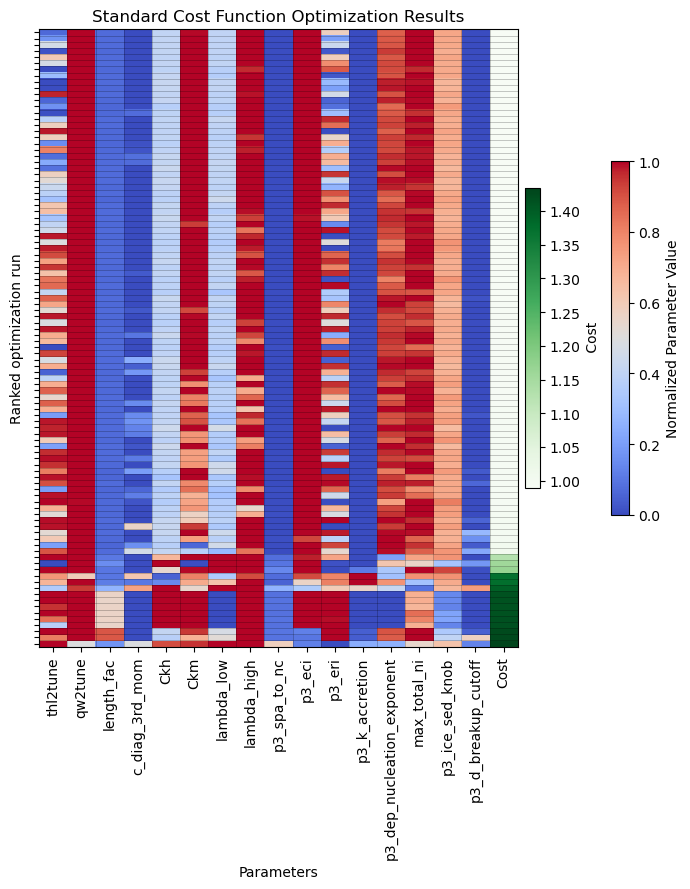

In [60]:
make_barcode_plot_opts(default_opts, 'Standard Cost Function Optimization Results')

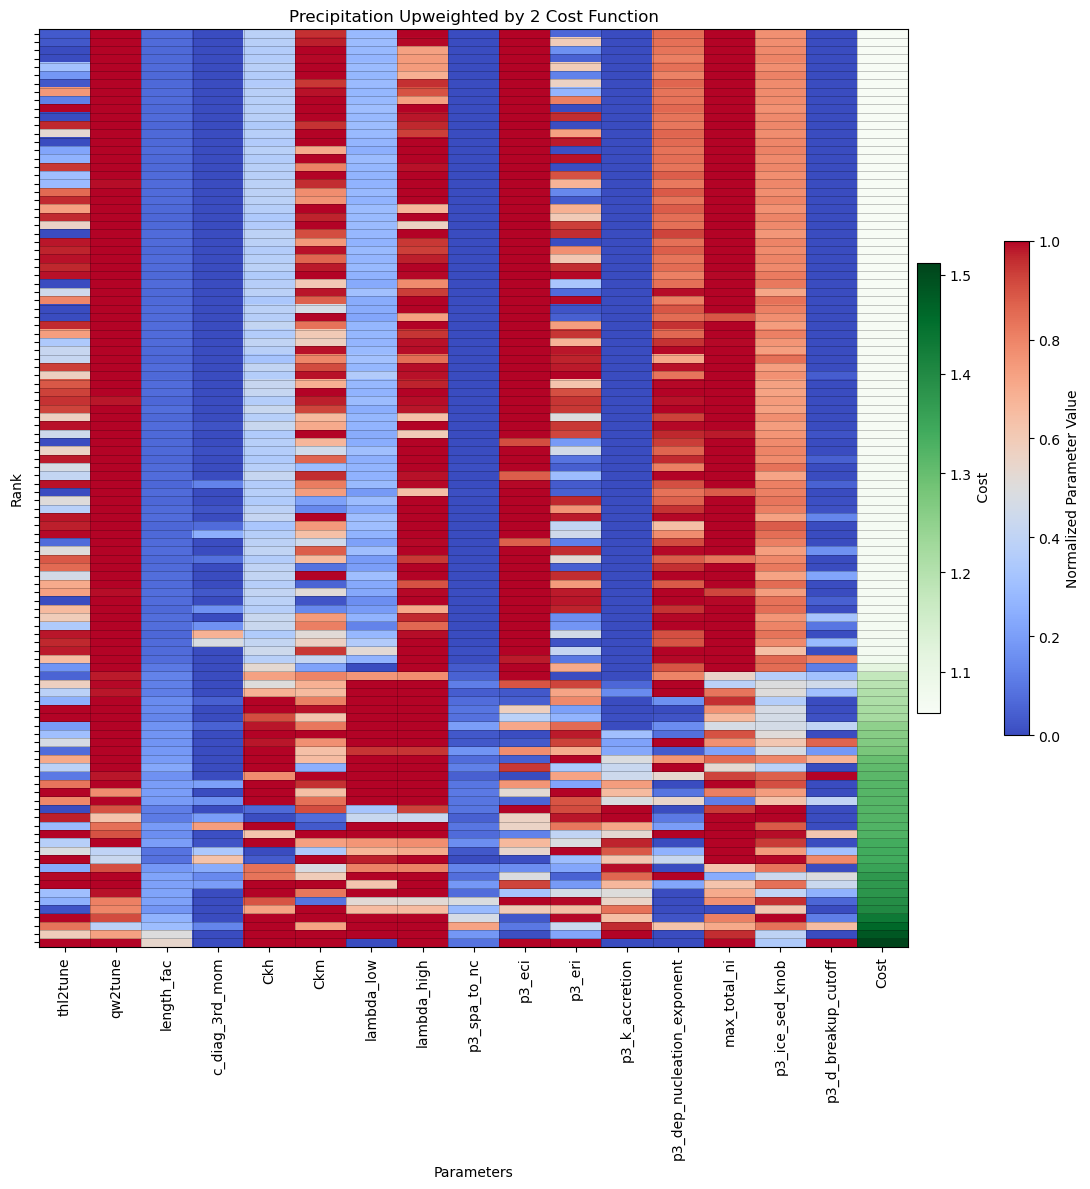

In [30]:
make_barcode_plot_opts(precip_opts, 'Precipitation Upweighted by 2 Cost Function')

In [31]:
make_barcode_plot_opts(precip4_opts, 'Precipitation Upweighted by 4 Cost Function')

NameError: name 'precip4_opts' is not defined

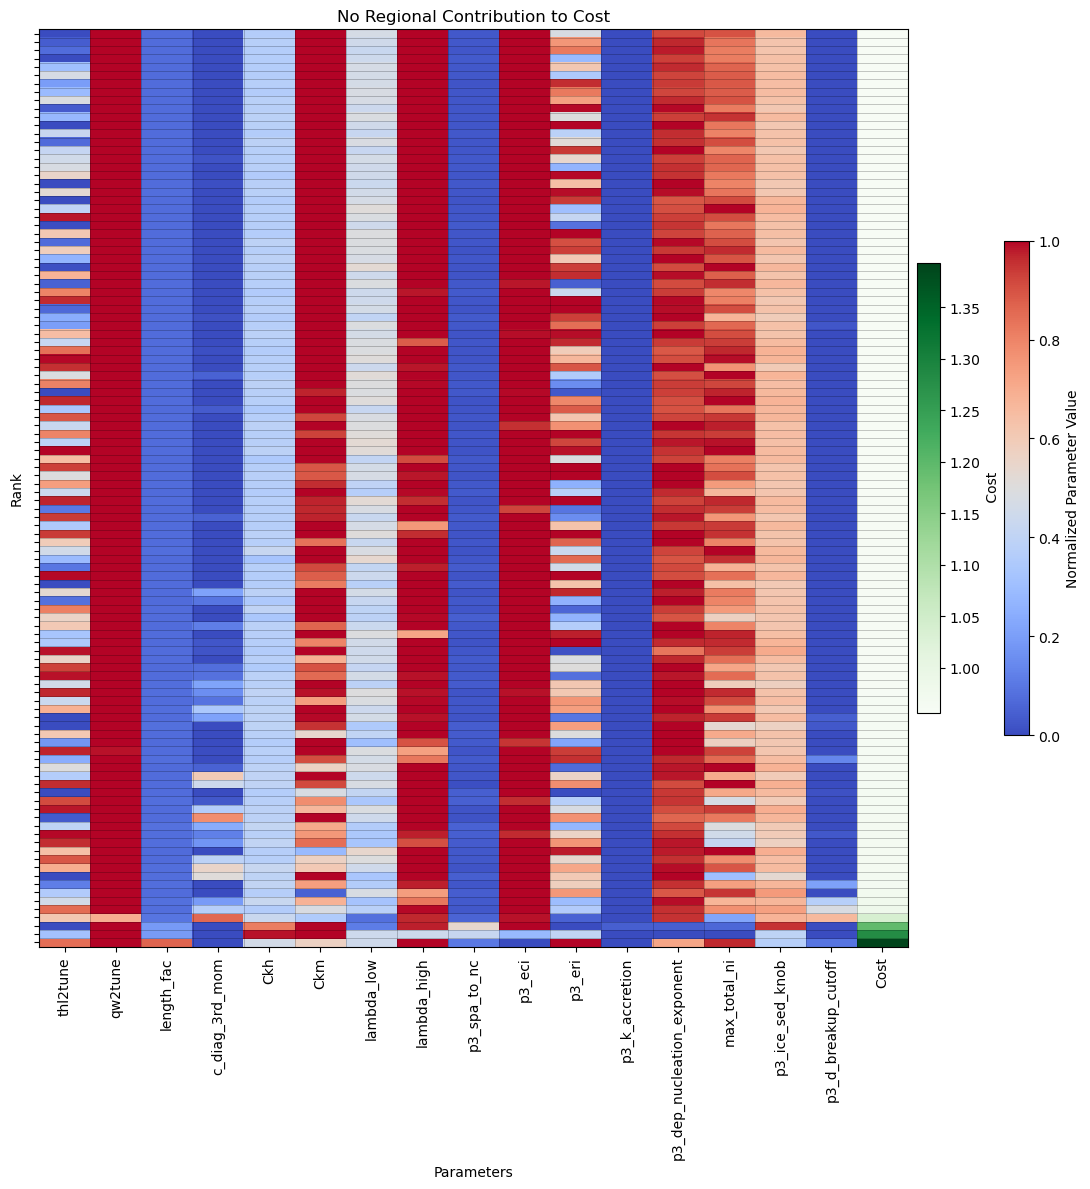

In [32]:
make_barcode_plot_opts(no_region_opts, 'No Regional Contribution to Cost')

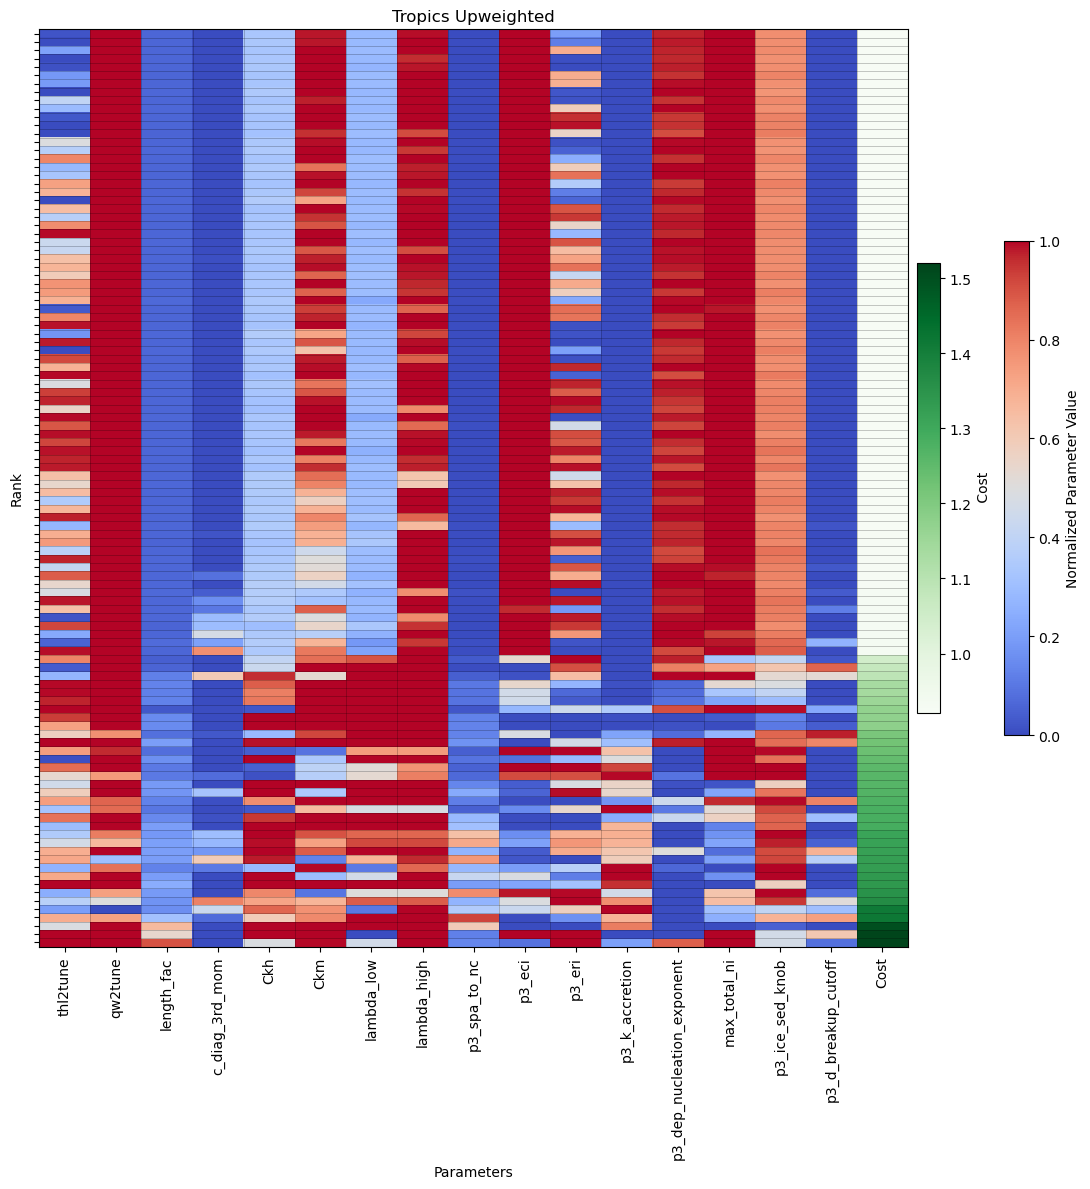

In [33]:
make_barcode_plot_opts(tropics_weighted_opts, 'Tropics Upweighted')

In [90]:
def make_barcode_plot_opts_compare(datset, title, labels, parameters_names_list):
    param_arrays = datset.iloc[:,0].apply(parse_param_string).to_list()
    
    main_params = np.vstack(param_arrays)  # shape: (n_param_sets, 16)
    
    n_param_sets = main_params.shape[0]
    
    fig, ax = plt.subplots(figsize=(10, max(2, 0.3 * n_param_sets)))
    
    # Plot main parameters
    im1 = ax.imshow(np.clip(main_params, 0, 1),
                    aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
    
    # Ticks and labels
    ax.set_yticks(np.arange(n_param_sets))
    ax.set_yticklabels(labels)
    
    ax.set_xticks(list(range(16)))
    ax.set_xticklabels(parameters_names_list, rotation=90)
    ax.set_xlabel('Parameters')
    ax.set_title(title)
    
    # Grid lines
    ax.set_xticks(np.arange(-.5, 16.5, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n_param_sets, 1), minor=True)
    ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.tick_params(which='minor', bottom=False, left=False)
    
    ax.set_ylim(n_param_sets - 0.5, -0.5)
    
    # Colorbar
    cbar1 = fig.colorbar(im1, ax=ax, fraction=0.025, pad=0.03, aspect=10, label='Normalized Parameter Value')
    
    plt.tight_layout()
    plt.show()

In [40]:
default_opts.iloc[[0]].param.values

array(['[6.80569424e-02 1.00000000e+00 7.08732904e-02 9.80700887e-06\n 4.02434512e-01 9.95495556e-01 3.99565682e-01 9.99999992e-01\n 2.37566443e-03 1.00000000e+00 5.74937476e-01 0.00000000e+00\n 8.71252431e-01 1.00000000e+00 7.17662155e-01 0.00000000e+00]'],
      dtype=object)

In [62]:
default_df = default_opts.iloc[[0]]
type(default_df.iloc[0,0]) 
default_df.iloc[0,0] = '[0.09090909 0.09090909 0.04040404 0.6969697  0.        0.         0.00900901 0.7997998  0.09090909 0.44444444 1.         0.669967   1.         0.02526316 0.        0.56      ]'
#str(X_train_norm[0].tolist())
default_df.iloc[0,1] = 0 #params_to_cost(X_train_norm[0])


In [63]:
top_opts_across_costfuns = pd.concat([default_df, default_opts.iloc[[0]], precip_opts.iloc[[0]], no_region_opts.iloc[[0]], tropics_weighted_opts.iloc[[0]]], axis=0) #precip4_opts.iloc[[0]],


/tmp/ipykernel_1551676/3777061637.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


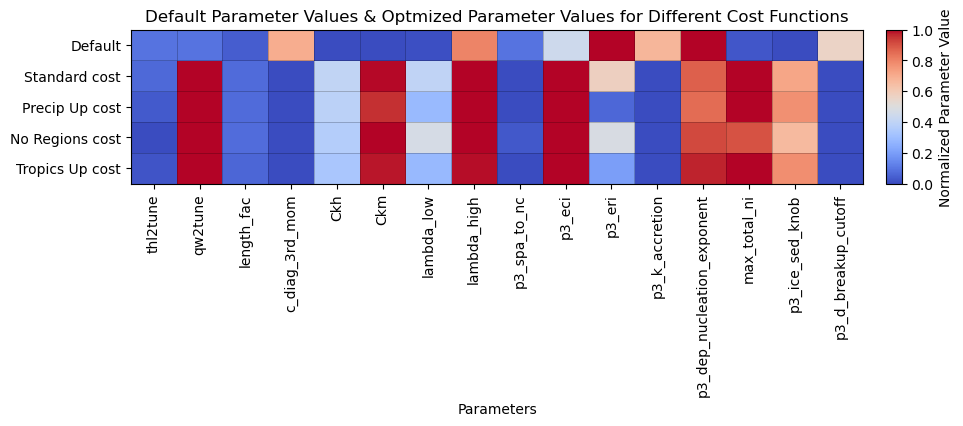

In [92]:
make_barcode_plot_opts_compare(top_opts_across_costfuns, 'Default Parameter Values & Optmized Parameter Values for Different Cost Functions', ['Default', 'Standard cost','Precip Up cost','No Regions cost','Tropics Up cost'], parameters_names_list)


### Analzing Optimal runs

In [97]:
parameters_names_list = ['thl2tune', 'qw2tune', 'length_fac', 'c_diag_3rd_mom', 'Ckh', 'Ckm',
       'lambda_low', 'lambda_high', 'p3_spa_to_nc', 'p3_eci', 'p3_eri',
       'p3_k_accretion', 'p3_dep_nucleation_exponent', 'max_total_ni',
       'p3_ice_sed_knob', 'p3_d_breakup_cutoff']

In [98]:
#filter variables in output - keep only the 4 of interest
to_keep = ['precip_total_surf_mass_flux','LiqWaterPath','RainWaterPath','SW_flux_up_at_model_top','LW_flux_up_at_model_top']
           
to_leave = ['SW_flux_dn','SW_flux_dn_at_model_bot','SW_flux_up','SW_flux_up_at_model_bot','SW_flux_dn_at_model_top', 'T_2m',
'T_mid', 'precip_ice_surf_mass_flux','precip_liq_surf_mass_flux','ps','qc','qi','qm','qr','qv','qv_2m','LW_flux_up','LW_flux_up_at_model_bot',
'IceWaterPath', 'LW_flux_dn','LW_flux_dn_at_model_bot','time_bnds', 'LongwaveCloudForcing', 'MeridionalVapFlux','ShortwaveCloudForcing','U','V', 
'VapWaterPath', 'ZonalVapFlux','bm','eddy_diff_mom', 'eff_radius_qc_at_cldtop','eff_radius_qi_at_cldtop', 'homme_T_mid_tend', 'homme_qv_tend',
'horiz_winds_at_model_bot', 'nc', 'ni', 'nr', 'omega', 'p3_T_mid_tend', 'p3_qv_tend', 'rrtmgp_T_mid_tend', 'sgs_buoy_flux', 'shoc_T_mid_tend',
'shoc_qv_tend', 'surf_evap', 'surf_mom_flux', 'surf_radiative_T','surf_sens_flux', 'surface_upward_latent_heat_flux', 'avg_count_ncol', 
'avg_count_ncol_lev', 'avg_count_ncol_dim', 'area', 'lat', 'lon']

In [99]:
def load_in_new_run(file_path):
    data = xr.open_dataset(file_path)
    #data_small = data.drop_vars(to_leave)
    data_small = data[to_keep]
    data_small['TotalLiqWaterPath'] = (data_small.LiqWaterPath + data_small.RainWaterPath)
    data_small = data_small.squeeze('time')
    return data_small

In [119]:
DY1_int_opt_data_Mar26_small = load_in_new_run('/global/cfs/cdirs/e3sm/jpaige3/optimizing_SCREAM_runs/optmar26_DY1_hassan/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc')
DY2_int_opt_data_Mar26_small = load_in_new_run('/global/cfs/cdirs/e3sm/jpaige3/optimizing_SCREAM_runs/optmar26_DY2_jpaige/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')

DY1_int_opt_data

In [ ]:
DY1_opt_ppe_dataset_mask = xr.Dataset()
DY2_opt_ppe_dataset_mask = xr.Dataset()

# DY1 Optimal
DY1_opt_ppe_dataset_mask['DY1_opt_precip_total_surf_mass_flux'] = DY1_int_opt_data_Mar26_small.precip_total_surf_mass_flux.where(np.isnan(DY1_PCP_obs) == False)
DY1_opt_ppe_dataset_mask['DY1_opt_TotalLiqWaterPath'] = DY1_int_opt_data_Mar26_small.TotalLiqWaterPath.where(np.isnan(DY1_TLWP_obs) == False)
DY1_opt_ppe_dataset_mask['DY1_opt_SW_flux_up_at_model_top'] = DY1_int_opt_data_Mar26_small.SW_flux_up_at_model_top.where(np.isnan(DY1_OSR_obs) == False)
DY1_opt_ppe_dataset_mask['DY1_opt_LW_flux_up_at_model_top'] = DY1_int_opt_data_Mar26_small.LW_flux_up_at_model_top.where(np.isnan(DY1_OLR_obs) == False)

# DY2 Optimal
DY2_opt_ppe_dataset_mask['DY2_opt_precip_total_surf_mass_flux'] = DY2_int_opt_data_Mar26_small.precip_total_surf_mass_flux.where(np.isnan(DY2_PCP_obs) == False)
DY2_opt_ppe_dataset_mask['DY2_opt_TotalLiqWaterPath'] = DY2_int_opt_data_Mar26_small.TotalLiqWaterPath.where(np.isnan(DY2_TLWP_obs) == False)
DY2_opt_ppe_dataset_mask['DY2_opt_SW_flux_up_at_model_top'] = DY2_int_opt_data_Mar26_small.SW_flux_up_at_model_top.where(np.isnan(DY2_OSR_obs) == False)
DY2_opt_ppe_dataset_mask['DY2_opt_LW_flux_up_at_model_top'] = DY2_int_opt_data_Mar26_small.LW_flux_up_at_model_top.where(np.isnan(DY2_OLR_obs) == False)


In [138]:
# DY1 Optimal
DY1_precip = DY1_int_opt_data_Mar26_small.precip_total_surf_mass_flux.where(np.isnan(DY1_PCP_obs) == False)
DY1_tlwp = DY1_int_opt_data_Mar26_small.TotalLiqWaterPath.where(np.isnan(DY1_TLWP_obs) == False)
DY1_osr = DY1_int_opt_data_Mar26_small.SW_flux_up_at_model_top.where(np.isnan(DY1_OSR_obs) == False)
DY1_olr = DY1_int_opt_data_Mar26_small.LW_flux_up_at_model_top.where(np.isnan(DY1_OLR_obs) == False)

# DY2 Optimal
DY2_precip = DY2_int_opt_data_Mar26_small.precip_total_surf_mass_flux.where(np.isnan(DY2_PCP_obs) == False)
DY2_tlwp = DY2_int_opt_data_Mar26_small.TotalLiqWaterPath.where(np.isnan(DY2_TLWP_obs) == False)
DY2_osr = DY2_int_opt_data_Mar26_small.SW_flux_up_at_model_top.where(np.isnan(DY2_OSR_obs) == False)
DY2_olr = DY2_int_opt_data_Mar26_small.LW_flux_up_at_model_top.where(np.isnan(DY2_OLR_obs) == False)

# DY1 Optimal zonal/regional/global dicts
DY1_opt_PCP_zonal = dict()
DY1_opt_TLWP_zonal = dict()
DY1_opt_OSR_zonal = dict()
DY1_opt_OLR_zonal = dict()

DY1_opt_PCP_regional = dict()
DY1_opt_TLWP_regional = dict()
DY1_opt_OSR_regional = dict()
DY1_opt_OLR_regional = dict()

DY1_opt_PCP_global = []
DY1_opt_TLWP_global = []
DY1_opt_OSR_global = []
DY1_opt_OLR_global = []

DY1_opt_PCP_zonal['opt'] = zonal_means_native(DY1_precip, area, lat, lon)
DY1_opt_TLWP_zonal['opt'] = zonal_means_native(DY1_tlwp, area, lat, lon)
DY1_opt_OSR_zonal['opt'] = zonal_means_native(DY1_osr, area, lat, lon)
DY1_opt_OLR_zonal['opt'] = zonal_means_native(DY1_olr, area, lat, lon)

DY1_opt_PCP_regional['opt'] = regional_means_native(DY1_precip, area, regions_file)
DY1_opt_TLWP_regional['opt'] = regional_means_native(DY1_tlwp, area, regions_file)
DY1_opt_OSR_regional['opt'] = regional_means_native(DY1_osr, area, regions_file)
DY1_opt_OLR_regional['opt'] = regional_means_native(DY1_olr, area, regions_file)

DY1_opt_PCP_global.append(global_means_native(DY1_precip, area))
DY1_opt_TLWP_global.append(global_means_native(DY1_tlwp, area))
DY1_opt_OSR_global.append(global_means_native(DY1_osr, area))
DY1_opt_OLR_global.append(global_means_native(DY1_olr, area))

# DY2 Optimal zonal/regional/global dicts
DY2_opt_PCP_zonal = dict()
DY2_opt_TLWP_zonal = dict()
DY2_opt_OSR_zonal = dict()
DY2_opt_OLR_zonal = dict()

DY2_opt_PCP_regional = dict()
DY2_opt_TLWP_regional = dict()
DY2_opt_OSR_regional = dict()
DY2_opt_OLR_regional = dict()

DY2_opt_PCP_global = []
DY2_opt_TLWP_global = []
DY2_opt_OSR_global = []
DY2_opt_OLR_global = []

DY2_opt_PCP_zonal['opt'] = zonal_means_native(DY2_precip, area, lat, lon)
DY2_opt_TLWP_zonal['opt'] = zonal_means_native(DY2_tlwp, area, lat, lon)
DY2_opt_OSR_zonal['opt'] = zonal_means_native(DY2_osr, area, lat, lon)
DY2_opt_OLR_zonal['opt'] = zonal_means_native(DY2_olr, area, lat, lon)

DY2_opt_PCP_regional['opt'] = regional_means_native(DY2_precip, area, regions_file)
DY2_opt_TLWP_regional['opt'] = regional_means_native(DY2_tlwp, area, regions_file)
DY2_opt_OSR_regional['opt'] = regional_means_native(DY2_osr, area, regions_file)
DY2_opt_OLR_regional['opt'] = regional_means_native(DY2_olr, area, regions_file)

DY2_opt_PCP_global.append(global_means_native(DY2_precip, area))
DY2_opt_TLWP_global.append(global_means_native(DY2_tlwp, area))
DY2_opt_OSR_global.append(global_means_native(DY2_osr, area))
DY2_opt_OLR_global.append(global_means_native(DY2_olr, area))

# Build DataFrames and concat — DY1
DY1_opt_PCP_z_df = pd.DataFrame.from_dict(DY1_opt_PCP_zonal, orient="index")
DY1_opt_PCP_r_df = pd.DataFrame.from_dict(DY1_opt_PCP_regional, orient="index")
DY1_opt_PCP_zrg = pd.concat([DY1_opt_PCP_z_df, DY1_opt_PCP_r_df], axis=1)
DY1_opt_PCP_zrg["global"] = DY1_opt_PCP_global
DY1_opt_PCP_zrg.columns = [f"DY1_{c}" for c in DY1_opt_PCP_zrg.columns]

DY2_opt_PCP_z_df = pd.DataFrame.from_dict(DY2_opt_PCP_zonal, orient="index")
DY2_opt_PCP_r_df = pd.DataFrame.from_dict(DY2_opt_PCP_regional, orient="index")
DY2_opt_PCP_zrg = pd.concat([DY2_opt_PCP_z_df, DY2_opt_PCP_r_df], axis=1)
DY2_opt_PCP_zrg["global"] = DY2_opt_PCP_global
DY2_opt_PCP_zrg.columns = [f"DY2_{c}" for c in DY2_opt_PCP_zrg.columns]
opt_PCP_zrg = pd.concat([DY1_opt_PCP_zrg, DY2_opt_PCP_zrg], axis=1)

DY1_opt_TLWP_z_df = pd.DataFrame.from_dict(DY1_opt_TLWP_zonal, orient="index")
DY1_opt_TLWP_r_df = pd.DataFrame.from_dict(DY1_opt_TLWP_regional, orient="index")
DY1_opt_TLWP_zrg = pd.concat([DY1_opt_TLWP_z_df, DY1_opt_TLWP_r_df], axis=1)
DY1_opt_TLWP_zrg["global"] = DY1_opt_TLWP_global
DY1_opt_TLWP_zrg.columns = [f"DY1_{c}" for c in DY1_opt_TLWP_zrg.columns]

DY2_opt_TLWP_z_df = pd.DataFrame.from_dict(DY2_opt_TLWP_zonal, orient="index")
DY2_opt_TLWP_r_df = pd.DataFrame.from_dict(DY2_opt_TLWP_regional, orient="index")
DY2_opt_TLWP_zrg = pd.concat([DY2_opt_TLWP_z_df, DY2_opt_TLWP_r_df], axis=1)
DY2_opt_TLWP_zrg["global"] = DY2_opt_TLWP_global
DY2_opt_TLWP_zrg.columns = [f"DY2_{c}" for c in DY2_opt_TLWP_zrg.columns]
opt_TLWP_zrg = pd.concat([DY1_opt_TLWP_zrg, DY2_opt_TLWP_zrg], axis=1)

DY1_opt_OSR_z_df = pd.DataFrame.from_dict(DY1_opt_OSR_zonal, orient="index")
DY1_opt_OSR_r_df = pd.DataFrame.from_dict(DY1_opt_OSR_regional, orient="index")
DY1_opt_OSR_zrg = pd.concat([DY1_opt_OSR_z_df, DY1_opt_OSR_r_df], axis=1)
DY1_opt_OSR_zrg["global"] = DY1_opt_OSR_global
DY1_opt_OSR_zrg.columns = [f"DY1_{c}" for c in DY1_opt_OSR_zrg.columns]

DY2_opt_OSR_z_df = pd.DataFrame.from_dict(DY2_opt_OSR_zonal, orient="index")
DY2_opt_OSR_r_df = pd.DataFrame.from_dict(DY2_opt_OSR_regional, orient="index")
DY2_opt_OSR_zrg = pd.concat([DY2_opt_OSR_z_df, DY2_opt_OSR_r_df], axis=1)
DY2_opt_OSR_zrg["global"] = DY2_opt_OSR_global
DY2_opt_OSR_zrg.columns = [f"DY2_{c}" for c in DY2_opt_OSR_zrg.columns]
opt_OSR_zrg = pd.concat([DY1_opt_OSR_zrg, DY2_opt_OSR_zrg], axis=1)

DY1_opt_OLR_z_df = pd.DataFrame.from_dict(DY1_opt_OLR_zonal, orient="index")
DY1_opt_OLR_r_df = pd.DataFrame.from_dict(DY1_opt_OLR_regional, orient="index")
DY1_opt_OLR_zrg = pd.concat([DY1_opt_OLR_z_df, DY1_opt_OLR_r_df], axis=1)
DY1_opt_OLR_zrg["global"] = DY1_opt_OLR_global
DY1_opt_OLR_zrg.columns = [f"DY1_{c}" for c in DY1_opt_OLR_zrg.columns]

DY2_opt_OLR_z_df = pd.DataFrame.from_dict(DY2_opt_OLR_zonal, orient="index")
DY2_opt_OLR_r_df = pd.DataFrame.from_dict(DY2_opt_OLR_regional, orient="index")
DY2_opt_OLR_zrg = pd.concat([DY2_opt_OLR_z_df, DY2_opt_OLR_r_df], axis=1)
DY2_opt_OLR_zrg["global"] = DY2_opt_OLR_global
DY2_opt_OLR_zrg.columns = [f"DY2_{c}" for c in DY2_opt_OLR_zrg.columns]
opt_OLR_zrg = pd.concat([DY1_opt_OLR_zrg, DY2_opt_OLR_zrg], axis=1)

# Drop polar columns and concat
opt_PCP_zrg = opt_PCP_zrg.drop(columns=['DY1_85.0', 'DY1_-85.0', 'DY1_-75.0', 'DY2_85.0', 'DY2_-85.0', 'DY2_-75.0'])
opt_TLWP_zrg = opt_TLWP_zrg.drop(columns=['DY1_85.0', 'DY1_-85.0', 'DY1_-75.0', 'DY2_85.0', 'DY2_-85.0', 'DY2_-75.0'])
opt_OSR_zrg = opt_OSR_zrg.drop(columns=['DY1_85.0', 'DY1_-85.0', 'DY1_-75.0', 'DY2_85.0', 'DY2_-85.0', 'DY2_-75.0'])
opt_OLR_zrg = opt_OLR_zrg.drop(columns=['DY1_85.0', 'DY1_-85.0', 'DY1_-75.0', 'DY2_85.0', 'DY2_-85.0', 'DY2_-75.0'])

opt_zrg = pd.concat([opt_PCP_zrg, opt_TLWP_zrg, opt_OSR_zrg, opt_OLR_zrg], axis=1)

opt_PCP_zrg_norm = Y_pipe_sk_ss_PCP.transform(opt_PCP_zrg)
opt_TLWP_zrg_norm = Y_pipe_sk_ss_TLWP.transform(opt_TLWP_zrg)
opt_OSR_zrg_norm = Y_pipe_sk_ss_OSR.transform(opt_OSR_zrg)
opt_OLR_zrg_norm = Y_pipe_sk_ss_OLR.transform(opt_OLR_zrg)

opt_zrg_norm = np.stack((opt_PCP_zrg_norm, opt_TLWP_zrg_norm, opt_OSR_zrg_norm, opt_OLR_zrg_norm), axis = 0)
opt_zrg_norm = np.transpose(opt_zrg_norm, (1, 2, 0))

In [141]:
default_cost = ZRG_cost_function_mae_weighted_print(Y_train_norm[0], obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict)
print('True default cost:', default_cost)
print('-----------------------------------------------')
print('pred default:')
print(params_to_cost_print(X_train_norm[0]))
print('-----------------------------------------------')
print('pred optimal:')
print(params_to_cost_print(optimal_params_norm[0])) #
print('-----------------------------------------------')
default_cost = ZRG_cost_function_mae_weighted_print(opt_zrg_norm[0], obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict)
print('True pred cost:', default_cost)


zonal_cost 0.4895625164111455 0.9940285682678223 regional_cost 0.4440091848373413 0.4386095851659775 global_cost 0.33576957384745276 0.3386601060628891
DY1 cost 0.4895625164111455 0.4440091848373413 0.33576957384745276 DY2 cost 0.9940285682678223 0.4386095851659775 0.3386601060628891
cost: 1.5203197672963142
True default cost: 1.5203197672963142
-----------------------------------------------
pred default:
zonal_cost 0.4892251400924581 0.9940658815574481 regional_cost 0.44348451187788634 0.4389759105392733 global_cost 0.33549742442537533 0.3389321263499244
DY1 cost 0.4892251400924581 0.44348451187788634 0.33549742442537533 DY2 cost 0.9940658815574481 0.4389759105392733 0.3389321263499244
cost: 1.5200904974211829
1.5200904974211829
-----------------------------------------------
pred optimal:
zonal_cost 0.33706531581290583 0.8386480716732431 regional_cost 0.32284762389613675 0.372380201612309 global_cost 0.07068148796348753 0.03703864263860501
DY1 cost 0.33706531581290583 0.322847623896

In [143]:
1.197491959358255/1.5203197672963142

0.7876579553312225

#### Comparing default runs

In [118]:

new_default_data = load_in_new_run('/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-dec3-2024/hh1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
#/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-dec3-2024/hh1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')


In [117]:
#New New default analysis, run on Frontier (10/9/2025) (I believe I ran this or a similar one)
newnew_default_data = load_in_new_run('/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/f00-dec2-2024-2444ff44ec/hh1024/m0000defle/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
#xr.open_dataset('/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-f00-dec2-2024-2444ff44ec/def-aug2019.ne1024pg2_ne1024pg2.F2010-SCREAMv1.f00-dec2-2024-2444ff44ec.2d.n2048.default/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2019-08-02-00000.nc')
#/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-dec3-2024/hh1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')


In [115]:
#New New New default analysis, on PM now, run by Noel (2/11/2026)
newnewnew_default_data = load_in_new_run('/pscratch/sd/n/ndk/e3sm_scratch/pm-gpu/p01-dec2-2024-2444ff44ec/ii1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')


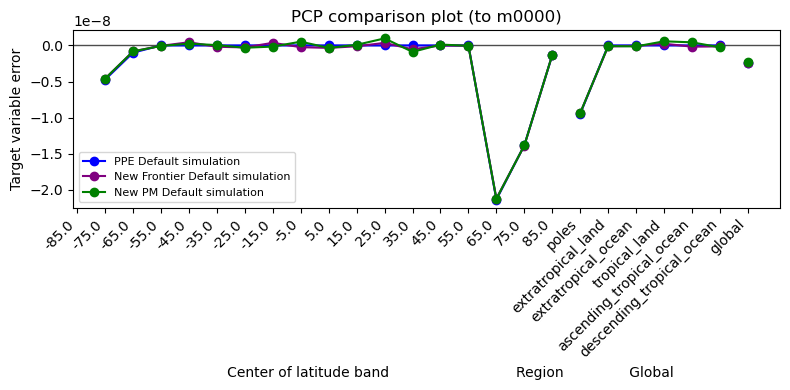

In [139]:
placeholder_zrgdataset_train = PCP_train
title = 'PCP'
#precip_total_surf_mass_flux
#TotalLiqWaterPath
#SW_flux_up_at_model_top
#LW_flux_up_at_model_top


# Configuration
datasets = [
    {
        'data': (control.precip_total_surf_mass_flux),
        #'data': (control.LiqWaterPath + control.RainWaterPath)
        'label': 'PPE Default simulation',
        'color': 'blue',
        'marker': 'o'
    },
    {
        'data': (newnew_default_data.precip_total_surf_mass_flux),
        'label': 'New Frontier Default simulation',
        'color': 'purple',
        'marker': 'o'
    },
        {
        'data': (newnewnew_default_data.precip_total_surf_mass_flux),
        'label': 'New PM Default simulation',
        'color': 'green',
        'marker': 'o'
    }
]

# Calculate means for all datasets
results = []
for dataset in datasets:
    result = {
        'zonal': zonal_means_native(dataset['data'], area, lat, lon),
        'regional': regional_means_native(dataset['data'], area, regions_file),
        'global': np.array([global_means_native(dataset['data'], area)]),
        'label': dataset['label'],
        'color': dataset['color'],
        'marker': dataset['marker']
    }
    results.append(result)

# Extract keys and create x positions (using first dataset as reference)
zonal_keys = list(results[0]['zonal'].keys())
regional_keys = list(results[0]['regional'].keys())
array_labels = ['global']

z_num = len(zonal_keys)
r_num = len(regional_keys)
all_num = z_num + r_num + 1

x_zonal = range(z_num)
x_regional = range(z_num, z_num + r_num)
x_global = range(z_num + r_num, z_num + r_num + 1)

# Create plot
plt.figure(figsize=(8, 4))
plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7)

# Plot each dataset
for result in results:
    zonal_values = list(result['zonal'].values())
    regional_values = list(result['regional'].values())
    global_value = result['global'][0]
    
    # Plot zonal means
    plt.plot(x_zonal, 
             np.array(zonal_values) - placeholder_zrgdataset_train.iloc[0, all_num:z_num+all_num],
             #np.array(zonal_values) - DY2_OLR_zrg_ppedataset.iloc[0, 0:z_num],
             f'-{result["marker"]}', 
             label=result['label'], 
             color=result['color'])
    
    # Plot regional means
    plt.plot(x_regional, 
             np.array(regional_values) - placeholder_zrgdataset_train.iloc[0, all_num+z_num:(z_num+r_num)+all_num],
             #np.array(regional_values) - DY2_OLR_zrg_ppedataset.iloc[0, z_num:(z_num+r_num)],
             f'-{result["marker"]}', 
             color=result['color'])
    
    # Plot global mean
    plt.plot(x_global, 
             global_value - placeholder_zrgdataset_train.iloc[0, -1], 
             #global_value - DY2_OLR_zrg_ppedataset.iloc[0, -1],
             f'-{result["marker"]}', 
             color=result['color'])

# Customize axes
all_keys = zonal_keys + regional_keys + array_labels
all_positions = list(x_zonal) + list(x_regional) + list(x_global)

plt.xticks(all_positions, all_keys, rotation=45, ha='right')
plt.xlabel("           Center of latitude band                             Region               Global")
plt.ylabel("Target variable error")
plt.title(title+" comparison plot (to m0000)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

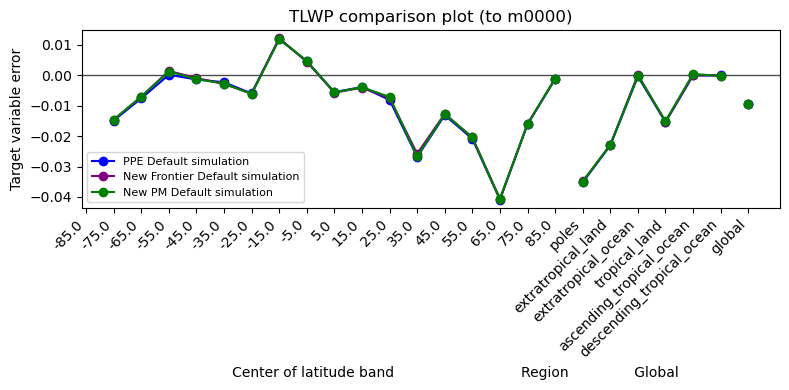

In [138]:
placeholder_zrgdataset_train = TLWP_train
title = 'TLWP'
#precip_total_surf_mass_flux
#TotalLiqWaterPath
#SW_flux_up_at_model_top
#LW_flux_up_at_model_top


# Configuration
datasets = [
    {
        #'data': (control.TotalLiqWaterPath),
        'data': (control.LiqWaterPath + control.RainWaterPath),
        'label': 'PPE Default simulation',
        'color': 'blue',
        'marker': 'o'
    },
    {
        'data': (newnew_default_data.TotalLiqWaterPath),
        'label': 'New Frontier Default simulation',
        'color': 'purple',
        'marker': 'o'
    },
        {
        'data': (newnewnew_default_data.TotalLiqWaterPath),
        'label': 'New PM Default simulation',
        'color': 'green',
        'marker': 'o'
    }
]

# Calculate means for all datasets
results = []
for dataset in datasets:
    result = {
        'zonal': zonal_means_native(dataset['data'], area, lat, lon),
        'regional': regional_means_native(dataset['data'], area, regions_file),
        'global': np.array([global_means_native(dataset['data'], area)]),
        'label': dataset['label'],
        'color': dataset['color'],
        'marker': dataset['marker']
    }
    results.append(result)

# Extract keys and create x positions (using first dataset as reference)
zonal_keys = list(results[0]['zonal'].keys())
regional_keys = list(results[0]['regional'].keys())
array_labels = ['global']

z_num = len(zonal_keys)
r_num = len(regional_keys)
all_num = z_num + r_num + 1

x_zonal = range(z_num)
x_regional = range(z_num, z_num + r_num)
x_global = range(z_num + r_num, z_num + r_num + 1)

# Create plot
plt.figure(figsize=(8, 4))
plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7)

# Plot each dataset
for result in results:
    zonal_values = list(result['zonal'].values())
    regional_values = list(result['regional'].values())
    global_value = result['global'][0]
    
    # Plot zonal means
    plt.plot(x_zonal, 
             np.array(zonal_values) - placeholder_zrgdataset_train.iloc[0, all_num:z_num+all_num],
             #np.array(zonal_values) - DY2_OLR_zrg_ppedataset.iloc[0, 0:z_num],
             f'-{result["marker"]}', 
             label=result['label'], 
             color=result['color'])
    
    # Plot regional means
    plt.plot(x_regional, 
             np.array(regional_values) - placeholder_zrgdataset_train.iloc[0, all_num+z_num:(z_num+r_num)+all_num],
             #np.array(regional_values) - DY2_OLR_zrg_ppedataset.iloc[0, z_num:(z_num+r_num)],
             f'-{result["marker"]}', 
             color=result['color'])
    
    # Plot global mean
    plt.plot(x_global, 
             global_value - placeholder_zrgdataset_train.iloc[0, -1], 
             #global_value - DY2_OLR_zrg_ppedataset.iloc[0, -1],
             f'-{result["marker"]}', 
             color=result['color'])

# Customize axes
all_keys = zonal_keys + regional_keys + array_labels
all_positions = list(x_zonal) + list(x_regional) + list(x_global)

plt.xticks(all_positions, all_keys, rotation=45, ha='right')
plt.xlabel("           Center of latitude band                             Region               Global")
plt.ylabel("Target variable error")
plt.title(title+" comparison plot (to m0000)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

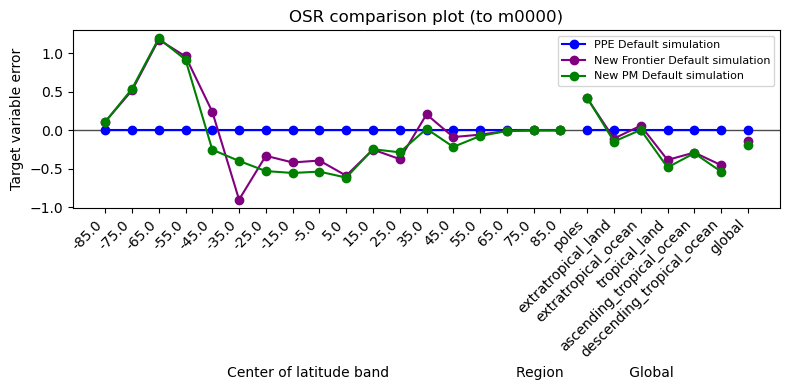

In [137]:
placeholder_zrgdataset_train = OSR_train
title = 'OSR'
#precip_total_surf_mass_flux
#TotalLiqWaterPath
#SW_flux_up_at_model_top
#LW_flux_up_at_model_top


# Configuration
datasets = [
    {
        'data': (control.SW_flux_up_at_model_top),
        #'data': (control.LiqWaterPath + control.RainWaterPath),
        'label': 'PPE Default simulation',
        'color': 'blue',
        'marker': 'o'
    },
    {
        'data': (newnew_default_data.SW_flux_up_at_model_top),
        'label': 'New Frontier Default simulation',
        'color': 'purple',
        'marker': 'o'
    },
        {
        'data': (newnewnew_default_data.SW_flux_up_at_model_top),
        'label': 'New PM Default simulation',
        'color': 'green',
        'marker': 'o'
    }
]

# Calculate means for all datasets
results = []
for dataset in datasets:
    result = {
        'zonal': zonal_means_native(dataset['data'], area, lat, lon),
        'regional': regional_means_native(dataset['data'], area, regions_file),
        'global': np.array([global_means_native(dataset['data'], area)]),
        'label': dataset['label'],
        'color': dataset['color'],
        'marker': dataset['marker']
    }
    results.append(result)

# Extract keys and create x positions (using first dataset as reference)
zonal_keys = list(results[0]['zonal'].keys())
regional_keys = list(results[0]['regional'].keys())
array_labels = ['global']

z_num = len(zonal_keys)
r_num = len(regional_keys)
all_num = z_num + r_num + 1

x_zonal = range(z_num)
x_regional = range(z_num, z_num + r_num)
x_global = range(z_num + r_num, z_num + r_num + 1)

# Create plot
plt.figure(figsize=(8, 4))
plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7)

# Plot each dataset
for result in results:
    zonal_values = list(result['zonal'].values())
    regional_values = list(result['regional'].values())
    global_value = result['global'][0]
    
    # Plot zonal means
    plt.plot(x_zonal, 
             np.array(zonal_values) - placeholder_zrgdataset_train.iloc[0, all_num:z_num+all_num],
             #np.array(zonal_values) - DY2_OLR_zrg_ppedataset.iloc[0, 0:z_num],
             f'-{result["marker"]}', 
             label=result['label'], 
             color=result['color'])
    
    # Plot regional means
    plt.plot(x_regional, 
             np.array(regional_values) - placeholder_zrgdataset_train.iloc[0, all_num+z_num:(z_num+r_num)+all_num],
             #np.array(regional_values) - DY2_OLR_zrg_ppedataset.iloc[0, z_num:(z_num+r_num)],
             f'-{result["marker"]}', 
             color=result['color'])
    
    # Plot global mean
    plt.plot(x_global, 
             global_value - placeholder_zrgdataset_train.iloc[0, -1], 
             #global_value - DY2_OLR_zrg_ppedataset.iloc[0, -1],
             f'-{result["marker"]}', 
             color=result['color'])

# Customize axes
all_keys = zonal_keys + regional_keys + array_labels
all_positions = list(x_zonal) + list(x_regional) + list(x_global)

plt.xticks(all_positions, all_keys, rotation=45, ha='right')
plt.xlabel("           Center of latitude band                             Region               Global")
plt.ylabel("Target variable error")
plt.title(title+" comparison plot (to m0000)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()